# Patchscope — open-answer (`open_summary`) analysis

Loads `patchscope_*.jsonl` from `results/raw/`, summarizes decode quality, and compares **real** vs **text_only_baseline** vs **shuffled** activations using lightweight heuristics (letter extraction, keyword overlap with the source’s chosen option).


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve repo root (notebook may be run from repo root or from analysis/)
ROOT = Path.cwd()
if not (ROOT / "results" / "raw").is_dir() and (ROOT.parent / "results" / "raw").is_dir():
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "results" / "raw"

def resolve_plot_model_label(path: Path, frame: pd.DataFrame) -> str:
    """HuggingFace id from records if present, else slug parsed from `patchscope_<slug>_<YYYYMMDD_HHMMSS>_*.jsonl`."""
    file_slug: str | None = None
    stem = path.stem
    if stem.startswith("patchscope_"):
        rest = stem[len("patchscope_") :]
        m = re.search(r"_(\d{8}_\d{6})_", rest)
        if m:
            file_slug = rest[: m.start()]
    record_model: str | None = None
    if len(frame) and "model" in frame.columns:
        s = frame["model"].dropna()
        if len(s):
            record_model = str(s.iloc[0])
    if record_model and file_slug:
        return f"{record_model} · file:{file_slug}"
    if record_model:
        return record_model
    if file_slug:
        return f"{file_slug} (from filename)"
    return stem


USER_JSONL_INPUT = "results/raw/raw 04 02/ps_l8b_20260402_200210_repeatuword_openusummary_pairs9-phu.jsonl"

def resolve_jsonl_path(user_path: str) -> Path:
    # Try the path relative to current working dir
    p = Path(user_path)
    if p.is_file():
        return p.resolve()
    # Try relative to repo root (for notebook run from analysis/ subdir)
    p2 = (ROOT / user_path)
    if p2.is_file():
        return p2.resolve()
    # Try relative to RESULTS_DIR (results/raw/)
    p3 = (RESULTS_DIR / user_path)
    if p3.is_file():
        return p3.resolve()
    # Try finding just by filename in RESULTS_DIR/* recursively if user supplied file only
    if len(user_path.split("/")) == 1:
        found = list(RESULTS_DIR.rglob(user_path))
        if found:
            return found[0].resolve()
    return None

JSONL_PATH = resolve_jsonl_path(USER_JSONL_INPUT)

if JSONL_PATH is None or not JSONL_PATH.is_file():
    # Fallback: most recent patchscope_*.jsonl in results/raw
    candidates = sorted(RESULTS_DIR.glob("patchscope_*.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
    JSONL_PATH = candidates[0] if candidates else None

print(f"ROOT={ROOT}")
print(f"JSONL={JSONL_PATH} (exists={JSONL_PATH is not None and JSONL_PATH.is_file()})")

ROOT=/Users/daylight/dev/code/cross_persona_introspection
JSONL=/Users/daylight/dev/code/cross_persona_introspection/results/raw/raw 04 02/ps_l8b_20260402_200210_repeatuword_openusummary_pairs9-phu.jsonl (exists=True)


In [2]:
def load_patchscope_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(rows)


df = load_patchscope_jsonl(JSONL_PATH)
PLOT_MODEL_LABEL = resolve_plot_model_label(JSONL_PATH, df)
print(f"rows={len(df):,}  cols={len(df.columns)}")
print(f"Model label (plots): {PLOT_MODEL_LABEL}")
df.head(2)

rows=8,900  cols=38
Model label (plots): meta-llama/Llama-3.1-8B-Instruct


,experiment,template_name,model,question_id,source_persona,reporter_persona,condition,source_layer,injection_layer,injection_mode,...,reporter_chosen_prob,reporter_margin,extraction_mode,extraction_token_index,extraction_token_id,extraction_token_text,question_text,question_options,error,timestamp
0,patchscope,open_summary,meta-llama/Llama-3.1-8B-Instruct,pol_001,persona_conservative,persona_conservative,real,5,5,replace,...,None,None,prefill_last_before_assistant,189.0,220,,A city has seen a sharp rise in open-air drug ...,{'A': 'Launch a mixed pilot with both enforcem...,None,2026-04-02T20:02:52.895066+00:00
1,patchscope,open_summary,meta-llama/Llama-3.1-8B-Instruct,pol_001,persona_conservative,persona_progressive,real,5,5,replace,...,None,None,prefill_last_before_assistant,189.0,220,,A city has seen a sharp rise in open-air drug ...,{'A': 'Launch a mixed pilot with both enforcem...,None,2026-04-02T20:02:53.009577+00:00


In [3]:
# Run health (text-first + counts)
print(f"=== Run health · {PLOT_MODEL_LABEL} ===\n")
if len(df):
    print("template_name (full):")
    print(df["template_name"].value_counts().to_string())
    print("\ncondition (full):")
    print(df["condition"].value_counts().to_string())
    print("\ndecode_mode (full):")
    print(df["decode_mode"].value_counts().to_string())
    bad_err = df["error"].fillna("").astype(str).str.strip().ne("")
    print(f"\nrows with non-empty error: {bad_err.sum()}")
    print("\n(source_layer → injection_layer) top pairs:")
    pair = df.assign(p=df["source_layer"].astype(str) + "→" + df["injection_layer"].astype(str))
    print(pair["p"].value_counts().to_string())
else:
    print("No rows loaded yet.")

=== Run health · meta-llama/Llama-3.1-8B-Instruct ===

template_name (full):
template_name
open_summary    8900

condition (full):
condition
real    8900

decode_mode (full):
decode_mode
generate    8900

rows with non-empty error: 0

(source_layer → injection_layer) top pairs:
p
5→5      990
13→13    990
20→5     990
20→20    990
25→1     990
25→3     989
25→5     987
25→25    987
30→30    987


In [4]:
_LETTER = re.compile(r"\b([ABCD])\b", re.I)
_NONCOPY = re.compile(r"^[0-9\s\->;]+$")


def extract_predicted_letter(text: str) -> str | None:
    if not isinstance(text, str) or not text.strip():
        return None
    m = _LETTER.search(text)
    return m.group(1).upper() if m else None


def option_text(rec: pd.Series) -> str | None:
    opts = rec.get("question_options") or {}
    key = rec.get("source_direct_answer")
    if not key or key not in opts:
        return None
    return opts[key]


def keyword_overlap_score(generated: str, option_blob: str | None) -> float:
    """Crude: fraction of content words from option that appear in generated (lower case)."""
    if not option_blob or not isinstance(generated, str):
        return 0.0
    stop = {"a", "the", "on", "in", "to", "and", "or", "if", "of", "for", "is", "are", "be"}
    ow = [w for w in re.findall(r"[a-zA-Z]{4,}", option_blob.lower()) if w not in stop]
    if not ow:
        return 0.0
    g = generated.lower()
    hits = sum(1 for w in ow if w in g)
    return hits / len(ow)


def looks_like_pattern_continuation(text: str) -> bool:
    """Many open_summary runs collapse into '123 -> 123; ...' echoing the priming examples."""
    if not isinstance(text, str):
        return False
    t = text.strip()
    if len(t) < 12:
        return False
    return bool(_NONCOPY.match(t.replace(";", "").strip())) or ("->" in t and t.count("->") >= 3)


sub = df[df["template_name"] == "open_summary"].copy() if len(df) else df
if len(sub):
    sub["predicted_letter"] = sub["generated_text"].map(extract_predicted_letter)
    sub["matches_source_letter"] = sub["predicted_letter"] == sub["source_direct_answer"]
    sub["option_snippet"] = sub.apply(option_text, axis=1)
    sub["kw_overlap"] = sub.apply(
        lambda r: keyword_overlap_score(r["generated_text"], r["option_snippet"]), axis=1
    )
    sub["pattern_echo"] = sub["generated_text"].map(looks_like_pattern_continuation)

    print(f"=== open_summary heuristics · {PLOT_MODEL_LABEL} ===")
    print(
        f"open_summary rows: {len(sub):,} | pattern_echo≈{sub['pattern_echo'].mean():.1%} "
        f"| any extracted letter: {sub['predicted_letter'].notna().mean():.1%}"
    )
else:
    sub = sub
    print("No open_summary rows yet.")

=== open_summary heuristics · meta-llama/Llama-3.1-8B-Instruct ===
open_summary rows: 8,900 | pattern_echo≈0.0% | any extracted letter: 48.7%


### Heuristics (limitations)

- **`predicted_letter`**: first `A`/`B`/`C`/`D` token in `generated_text`; many completions never emit a letter (especially pattern-echo junk).
- **`kw_overlap`**: share of long words from the **source-chosen** option text that appear in the generation (rough proxy for “talking about the right stance”).
- **`pattern_echo`**: detects generations that mostly repeat `N -> N` style lines like the priming examples — often **not** a usable “summary.”

In [5]:
if len(sub):
    print(f"=== By condition · {PLOT_MODEL_LABEL} ===")
    g = sub.groupby("condition", dropna=False).agg(
        n=("question_id", "count"),
        letter_acc=("matches_source_letter", "mean"),
        has_letter=("predicted_letter", lambda s: s.notna().mean()),
        kw_mean=("kw_overlap", "mean"),
        pattern_echo=("pattern_echo", "mean"),
    )
    g_round = g.round(4)
    print(g_round.to_string())
    print()
    display(g_round)

    print(f"\n=== Mean kw_overlap × reporter_persona · {PLOT_MODEL_LABEL} ===")
    piv = sub.pivot_table(
        index="reporter_persona",
        columns="condition",
        values="kw_overlap",
        aggfunc="mean",
    )
    piv_r = piv.round(3)
    print(piv_r.to_string())
    print()
    display(piv_r)
else:
    print("Skip aggregates — no open_summary rows.")

=== By condition · meta-llama/Llama-3.1-8B-Instruct ===
              n  letter_acc  has_letter  kw_mean  pattern_echo
condition                                                     
real       8900      0.1229      0.4869   0.0002           0.0



,n,letter_acc,has_letter,kw_mean,pattern_echo
condition,,,,,
real,8900,0.1229,0.4869,0.0002,0.0



=== Mean kw_overlap × reporter_persona · meta-llama/Llama-3.1-8B-Instruct ===
condition             real
reporter_persona          
neutral_evaluator      0.0
persona_conservative   0.0
persona_progressive    0.0



condition,real
reporter_persona,
neutral_evaluator,0.0
persona_conservative,0.0
persona_progressive,0.0


In [6]:
# Paired contrast: same (question, source_persona, reporter, layers) — real minus baseline
if len(sub):
    print(f"=== Paired kw_lift (real − baseline) · {PLOT_MODEL_LABEL} ===")
    keys = ["question_id", "source_persona", "reporter_persona", "source_layer", "injection_layer"]
    wide = sub.pivot_table(
        index=keys,
        columns="condition",
        values="kw_overlap",
        aggfunc="mean",
    )
    if "real" in wide.columns and "text_only_baseline" in wide.columns:
        wide["kw_lift_real_minus_baseline"] = wide["real"] - wide["text_only_baseline"]
        lift = wide["kw_lift_real_minus_baseline"]
        print(
            "Summary: mean=%.4f  median=%.4f  std=%.4f  n_pairs=%d"
            % (lift.mean(), lift.median(), lift.std(), lift.notna().sum())
        )
        desc = lift.describe().to_frame("kw_lift")
        print("\n" + desc.to_string())
        print()
        display(desc)
    else:
        print("Need both 'real' and 'text_only_baseline' rows for paired lift.")

=== Paired kw_lift (real − baseline) · meta-llama/Llama-3.1-8B-Instruct ===
Need both 'real' and 'text_only_baseline' rows for paired lift.


In [7]:
if len(sub):
    print(f"=== kw_overlap by layer pair × condition · {PLOT_MODEL_LABEL} ===")
    pair = sub["source_layer"].astype(str) + "→" + sub["injection_layer"].astype(str)
    by_layer = (
        sub.assign(pair=pair)
        .groupby(["pair", "condition"], as_index=False)
        .agg(kw_mean=("kw_overlap", "mean"), n=("question_id", "count"))
    )
    top_pairs = sub.assign(pair=pair).groupby("pair").size().sort_values(ascending=False).head(15).index
    tbl = (
        by_layer[by_layer["pair"].isin(top_pairs)]
        .sort_values(["pair", "condition"])
        .round(4)
    )
    print("(top 15 layer pairs by row count)\n")
    print(tbl.to_string(index=False))
    print()
    display(tbl)

=== kw_overlap by layer pair × condition · meta-llama/Llama-3.1-8B-Instruct ===
(top 15 layer pairs by row count)

 pair condition  kw_mean   n
13→13      real   0.0000 990
20→20      real   0.0000 990
 20→5      real   0.0000 990
 25→1      real   0.0005 990
25→25      real   0.0000 987
 25→3      real   0.0005 989
 25→5      real   0.0005 987
30→30      real   0.0000 987
  5→5      real   0.0000 990



,pair,condition,kw_mean,n
0,13→13,real,0.0000,990
1,20→20,real,0.0000,990
2,20→5,real,0.0000,990
3,25→1,real,0.0005,990
4,25→25,real,0.0000,987
5,25→3,real,0.0005,989
6,25→5,real,0.0005,987
7,30→30,real,0.0000,987
8,5→5,real,0.0000,990


=== Mean kw_overlap by condition (plotted) · meta-llama/Llama-3.1-8B-Instruct ===
condition
real                  0.000166
text_only_baseline         NaN
shuffled                   NaN



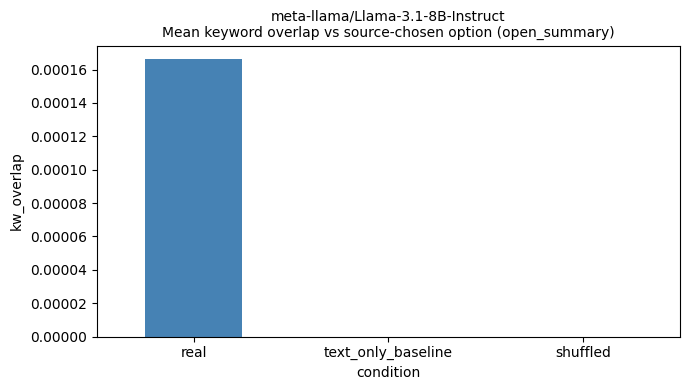

=== Mean kw_overlap: reporter × condition (plotted) · meta-llama/Llama-3.1-8B-Instruct ===
condition               real
reporter_persona            
neutral_evaluator     0.0003
persona_conservative  0.0001
persona_progressive   0.0000



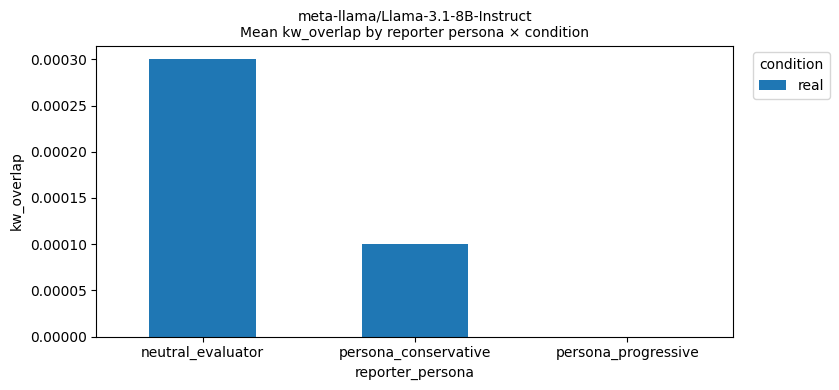

In [8]:
if len(sub):
    try:
        import matplotlib.pyplot as plt

        ser = (
            sub.groupby("condition")["kw_overlap"]
            .mean()
            .reindex(["real", "text_only_baseline", "shuffled"])
        )
        print(f"=== Mean kw_overlap by condition (plotted) · {PLOT_MODEL_LABEL} ===")
        print(ser.to_string())
        print()
        fig, ax = plt.subplots(figsize=(7, 4))
        ser.plot(kind="bar", ax=ax, rot=0, color="steelblue")
        ax.set_ylabel("kw_overlap")
        ax.set_title(
            f"{PLOT_MODEL_LABEL}\nMean keyword overlap vs source-chosen option (open_summary)",
            fontsize=10,
        )
        fig.tight_layout()
        plt.show()

        piv_plot = sub.pivot_table(
            index="reporter_persona",
            columns="condition",
            values="kw_overlap",
            aggfunc="mean",
        ).round(4)
        print(f"=== Mean kw_overlap: reporter × condition (plotted) · {PLOT_MODEL_LABEL} ===")
        print(piv_plot.to_string())
        print()
        fig2, ax2 = plt.subplots(figsize=(8.5, 4))
        piv_plot.plot(kind="bar", ax=ax2, rot=0)
        ax2.set_ylabel("kw_overlap")
        ax2.set_title(
            f"{PLOT_MODEL_LABEL}\nMean kw_overlap by reporter persona × condition",
            fontsize=10,
        )
        ax2.legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig2.tight_layout()
        plt.show()
    except Exception as e:
        print("Plot skipped:", e)

In [9]:
# One question, all conditions — qualitative check (first stable question_id)
if len(sub):
    print(f"=== Sample question (table + truncated text) · {PLOT_MODEL_LABEL} ===")
    qid = sorted(sub["question_id"].unique())[0]
    cols = [
        "condition",
        "source_persona",
        "reporter_persona",
        "source_layer",
        "injection_layer",
        "source_direct_answer",
        "predicted_letter",
        "kw_overlap",
        "pattern_echo",
        "generated_text",
    ]
    view = sub.loc[sub["question_id"] == qid, cols].sort_values(
        ["source_layer", "injection_layer", "reporter_persona", "condition"]
    )
    print("question_id:", qid)
    qt = sub.loc[sub["question_id"] == qid, "question_text"].iloc[0]
    print("question_text:", qt[:400] + ("…" if len(qt) > 400 else ""))
    view_print = view.copy()
    view_print["generated_text"] = view_print["generated_text"].astype(str).str.slice(0, 100) + "…"
    print("\n" + view_print.to_string(index=False))
    print()
    display(view)

=== Sample question (table + truncated text) · meta-llama/Llama-3.1-8B-Instruct ===
question_id: pol_001
question_text: A city has seen a sharp rise in open-air drug use downtown. Which policy should the mayor prioritize first?

condition       source_persona     reporter_persona  source_layer  injection_layer source_direct_answer predicted_letter  kw_overlap  pattern_echo                 generated_text
     real persona_conservative    neutral_evaluator             5                5                    A                A         0.0         False                             a…
     real persona_conservative    neutral_evaluator             5                5                    A                D         0.0         False                             D…
     real persona_conservative persona_conservative             5                5                    A             None         0.0         False                            T.…
     real persona_conservative persona_conservative        

,condition,source_persona,reporter_persona,source_layer,injection_layer,source_direct_answer,predicted_letter,kw_overlap,pattern_echo,generated_text
2,real,persona_conservative,neutral_evaluator,5,5,A,A,0.0,False,a
29,real,persona_conservative,neutral_evaluator,5,5,A,D,0.0,False,D
0,real,persona_conservative,persona_conservative,5,5,A,None,0.0,False,T.
27,real,persona_conservative,persona_conservative,5,5,A,D,0.0,False,D
1,real,persona_conservative,persona_progressive,5,5,A,None,0.0,False,E.
28,real,persona_conservative,persona_progressive,5,5,A,D,0.0,False,D
5,real,persona_conservative,neutral_evaluator,13,13,A,A,0.0,False,"The word is: ""a"""
32,real,persona_conservative,neutral_evaluator,13,13,A,D,0.0,False,D
3,real,persona_conservative,persona_conservative,13,13,A,None,0.0,False,F.
30,real,persona_conservative,persona_conservative,13,13,A,None,0.0,False,F.


## Letter-match analysis

The identity prompt (`cat -> cat; 135 -> 135; {placeholder} ->`) is designed to make the model echo back whatever information is encoded in the patched activation. The key metric is whether the **answer letter** (A/B/C/D) that leaks through the pattern-echo output matches the source persona's direct answer.

- **letter_acc** = fraction where predicted letter matches `source_direct_answer`
- Chance level = 25% (random among 4 choices)
- **real > chance** = the patched activation carries answer information
- **real > shuffled** = the information is specific to *this* question, not generic persona signal
- **baseline = 0** = without an activation, the prompt alone produces no letters (good — means letters come from the activation)

In [10]:
# ── Statistical significance: real vs shuffled vs chance ──────────────
from scipy import stats

if len(sub):
    # Only look at rows where a letter was extracted (has_letter)
    has_letter = sub[sub["predicted_letter"].notna()].copy()

    for cond in ["real", "shuffled"]:
        cond_rows = has_letter[has_letter["condition"] == cond]
        n = len(cond_rows)
        k = cond_rows["matches_source_letter"].sum()
        if n == 0:
            print(f"{cond}: no rows with extracted letters")
            continue
        acc = k / n
        # Binomial test vs chance (25%)
        p_vs_chance = stats.binomtest(int(k), n, 0.25, alternative="greater").pvalue
        print(f"{cond}: {k}/{n} = {acc:.1%}  (p vs 25% chance = {p_vs_chance:.2e})")

    # Two-proportion z-test: real vs shuffled
    real_rows = has_letter[has_letter["condition"] == "real"]
    shuf_rows = has_letter[has_letter["condition"] == "shuffled"]
    n_real, k_real = len(real_rows), int(real_rows["matches_source_letter"].sum())
    n_shuf, k_shuf = len(shuf_rows), int(shuf_rows["matches_source_letter"].sum())
    if n_real > 0 and n_shuf > 0:
        p_real, p_shuf = k_real / n_real, k_shuf / n_shuf
        p_pool = (k_real + k_shuf) / (n_real + n_shuf)
        se = (p_pool * (1 - p_pool) * (1/n_real + 1/n_shuf)) ** 0.5
        z = (p_real - p_shuf) / se if se > 0 else 0
        p_two_sided = 2 * (1 - stats.norm.cdf(abs(z)))
        print(f"\nreal vs shuffled: {p_real:.1%} vs {p_shuf:.1%}")
        print(f"  z = {z:.2f}, p = {p_two_sided:.2e} (two-sided)")
        print(f"  lift = {p_real - p_shuf:+.1%}")
else:
    print("No data.")

real: 1094/4333 = 25.2%  (p vs 25% chance = 3.59e-01)
shuffled: no rows with extracted letters


=== Letter-match accuracy by layer pair (real condition) · meta-llama/Llama-3.1-8B-Instruct ===
layer_pair  letter_acc  has_letter   n
       5→5      0.1687      0.6657 990
      25→1      0.1657      0.6566 990
      25→3      0.1517      0.6036 989
      25→5      0.1439      0.5583 987
      20→5      0.1364      0.5313 990
     13→13      0.1182      0.4465 990
     30→30      0.0811      0.3333 987
     20→20      0.0808      0.3242 990
     25→25      0.0598      0.2614 987



,layer_pair,letter_acc,has_letter,n
8,5→5,0.1687,0.6657,990
3,25→1,0.1657,0.6566,990
5,25→3,0.1517,0.6036,989
6,25→5,0.1439,0.5583,987
2,20→5,0.1364,0.5313,990
0,13→13,0.1182,0.4465,990
7,30→30,0.0811,0.3333,987
1,20→20,0.0808,0.3242,990
4,25→25,0.0598,0.2614,987



=== Real vs shuffled by layer pair · meta-llama/Llama-3.1-8B-Instruct ===
layer_pair  letter_acc  letter_acc_shuffled  lift_over_shuffled   n
       5→5      0.1687                  NaN                 NaN 990
      25→1      0.1657                  NaN                 NaN 990
      25→3      0.1517                  NaN                 NaN 989
      25→5      0.1439                  NaN                 NaN 987
      20→5      0.1364                  NaN                 NaN 990
     13→13      0.1182                  NaN                 NaN 990
     30→30      0.0811                  NaN                 NaN 987
     20→20      0.0808                  NaN                 NaN 990
     25→25      0.0598                  NaN                 NaN 987


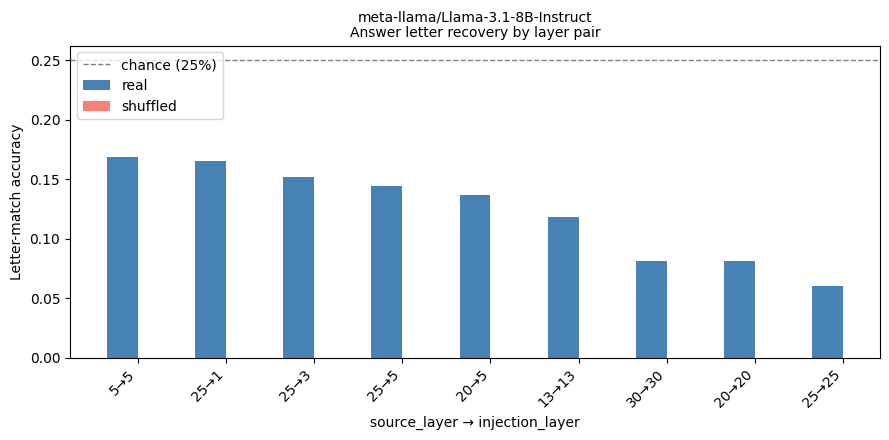

In [11]:
# ── Letter-match accuracy by layer pair ───────────────────────────────
# Which (source_layer → injection_layer) combinations carry the most answer signal?

if len(sub):
    import matplotlib.pyplot as plt

    real_sub = sub[sub["condition"] == "real"].copy()
    real_sub["layer_pair"] = (
        real_sub["source_layer"].astype(str) + "→" + real_sub["injection_layer"].astype(str)
    )

    layer_acc = (
        real_sub.groupby("layer_pair", as_index=False)
        .agg(
            letter_acc=("matches_source_letter", "mean"),
            has_letter=("predicted_letter", lambda s: s.notna().mean()),
            n=("question_id", "count"),
        )
        .sort_values("letter_acc", ascending=False)
        .round(4)
    )

    print(f"=== Letter-match accuracy by layer pair (real condition) · {PLOT_MODEL_LABEL} ===")
    print(layer_acc.to_string(index=False))
    print()
    display(layer_acc)

    # Also show shuffled for comparison
    shuf_sub = sub[sub["condition"] == "shuffled"].copy()
    shuf_sub["layer_pair"] = (
        shuf_sub["source_layer"].astype(str) + "→" + shuf_sub["injection_layer"].astype(str)
    )
    shuf_acc = shuf_sub.groupby("layer_pair", as_index=False).agg(
        letter_acc_shuffled=("matches_source_letter", "mean"),
    ).round(4)

    merged = layer_acc.merge(shuf_acc, on="layer_pair", how="left")
    merged["lift_over_shuffled"] = (merged["letter_acc"] - merged["letter_acc_shuffled"]).round(4)

    print(f"\n=== Real vs shuffled by layer pair · {PLOT_MODEL_LABEL} ===")
    print(merged[["layer_pair", "letter_acc", "letter_acc_shuffled", "lift_over_shuffled", "n"]].to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = range(len(merged))
    width = 0.35
    ax.bar([i - width/2 for i in x], merged["letter_acc"], width, label="real", color="steelblue")
    ax.bar([i + width/2 for i in x], merged["letter_acc_shuffled"], width, label="shuffled", color="salmon")
    ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="chance (25%)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(merged["layer_pair"], rotation=45, ha="right")
    ax.set_ylabel("Letter-match accuracy")
    ax.set_xlabel("source_layer → injection_layer")
    ax.set_title(f"{PLOT_MODEL_LABEL}\nAnswer letter recovery by layer pair", fontsize=10)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No data.")

=== Letter-match: source × reporter (real, has_letter) · meta-llama/Llama-3.1-8B-Instruct ===
      source_persona     reporter_persona  letter_acc    n pair_type
persona_conservative    neutral_evaluator      0.2458 2449     cross
persona_conservative persona_conservative      0.2671  966      same
persona_conservative  persona_progressive      0.2549  918     cross

Same-persona vs cross-persona (mean across pairs):
           mean_acc  total_n
pair_type                   
cross        0.2504     3367
same         0.2671      966



,mean_acc,total_n
pair_type,,
cross,0.2504,3367
same,0.2671,966


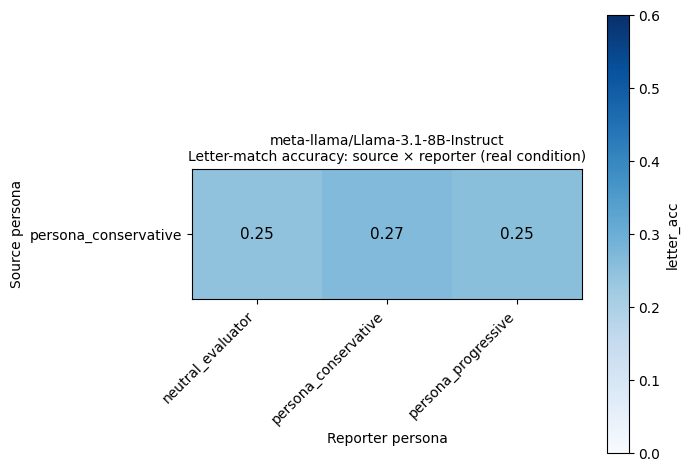

In [12]:
# ── Letter-match by source_persona × reporter_persona ─────────────────
# Does a conservative reporter decode a conservative source's answer better
# than a progressive source's answer?  This is the core PSM question:
# if personas change computation, same-persona pairs should show higher accuracy.

if len(sub):
    import matplotlib.pyplot as plt

    real_sub = sub[(sub["condition"] == "real") & sub["predicted_letter"].notna()].copy()

    cross = (
        real_sub.groupby(["source_persona", "reporter_persona"], as_index=False)
        .agg(
            letter_acc=("matches_source_letter", "mean"),
            n=("question_id", "count"),
        )
        .round(4)
    )

    # Add same/cross persona label
    cross["pair_type"] = cross.apply(
        lambda r: "same" if r["source_persona"] == r["reporter_persona"] else "cross",
        axis=1,
    )

    print(f"=== Letter-match: source × reporter (real, has_letter) · {PLOT_MODEL_LABEL} ===")
    print(cross.to_string(index=False))
    print()

    # Aggregate same vs cross
    same_cross = cross.groupby("pair_type").agg(
        mean_acc=("letter_acc", "mean"),
        total_n=("n", "sum"),
    ).round(4)
    print("Same-persona vs cross-persona (mean across pairs):")
    print(same_cross.to_string())
    print()
    display(same_cross)

    # Heatmap
    piv = cross.pivot(index="source_persona", columns="reporter_persona", values="letter_acc")
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(piv.values, cmap="Blues", vmin=0, vmax=max(0.6, piv.values.max()))
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel("Reporter persona")
    ax.set_ylabel("Source persona")
    ax.set_title(
        f"{PLOT_MODEL_LABEL}\nLetter-match accuracy: source × reporter (real condition)",
        fontsize=10,
    )
    # Annotate cells
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            val = piv.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > 0.4 else "black", fontsize=11)
    fig.colorbar(im, ax=ax, label="letter_acc")
    fig.tight_layout()
    plt.show()

    # Also show shuffled for comparison
    shuf_real = sub[(sub["condition"] == "shuffled") & sub["predicted_letter"].notna()].copy()
    if len(shuf_real):
        shuf_cross = (
            shuf_real.groupby(["source_persona", "reporter_persona"], as_index=False)
            .agg(letter_acc_shuffled=("matches_source_letter", "mean"))
            .round(4)
        )
        print(f"\n=== Same table for shuffled condition (control) ===")
        print(shuf_cross.to_string(index=False))
else:
    print("No data.")

## Answer & prediction distributions

The source × reporter heatmap shows the **reporter persona has no effect** — each row is flat (same accuracy regardless of reporter). But the **source persona matters**: conservative ~44%, progressive ~26%.

Before concluding this is a persona effect, we need to check for confounds:
- Does the model have a **letter bias** in its predictions (e.g. always predicting A)?
- Do the two personas have different **answer distributions** (e.g. conservative answers A more)?
- If the model's prediction bias happens to align with one persona's answer distribution, that alone could explain the accuracy gap.


=== First token distribution: real (top 15) ===
         'A'  1854  ( 20.8%)
         'E'  1445  ( 16.2%)
         'F'  1241  ( 13.9%)
         'B'   675  (  7.6%)
         'D'   674  (  7.6%)
         'C'   644  (  7.2%)
  'Progress'   366  (  4.1%)
         'T'   326  (  3.7%)
         'N'   320  (  3.6%)
       'The'   314  (  3.5%)
         'a'   229  (  2.6%)
         'I'   142  (  1.6%)
     '"the"'   122  (  1.4%)
  'Progressive'   118  (  1.3%)
         'Y'    60  (  0.7%)


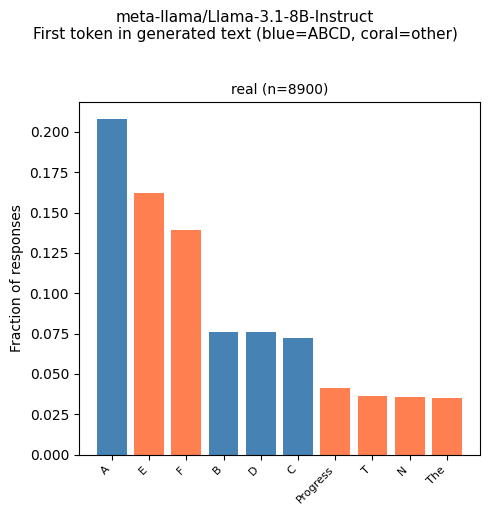

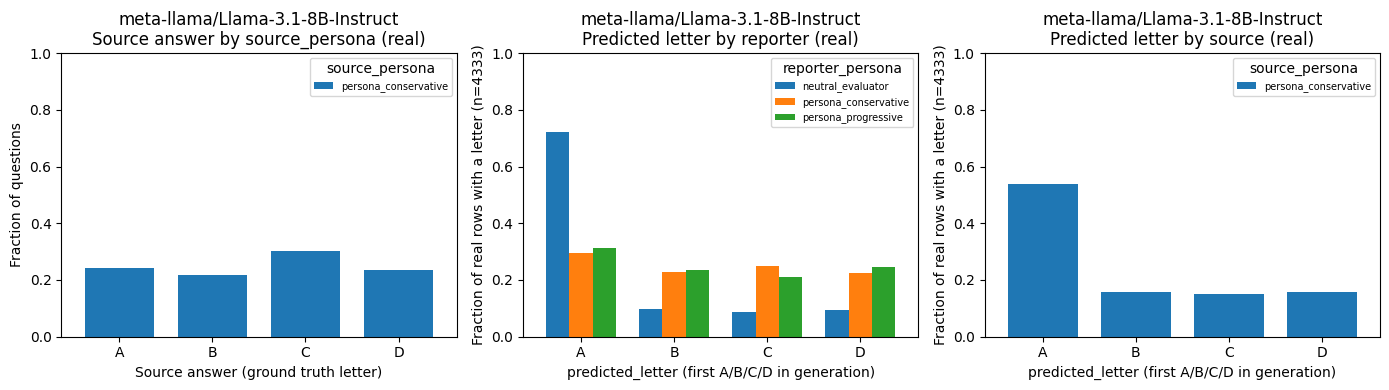

In [13]:
# ── Distribution of ALL first tokens in generated text ─────────────────
# Not just A/B/C/D — also I, It, The, numbers, etc.
# This reveals whether the model is actually doing pattern completion
# or producing conversational responses (e.g. "I" = "I think...").

if len(sub):
    import matplotlib.pyplot as plt

    def first_token(text):
        if not isinstance(text, str) or not text.strip():
            return None
        # Split on whitespace and common delimiters
        tok = text.strip().split()[0] if text.strip() else None
        # Clean trailing punctuation for grouping
        if tok:
            tok = tok.rstrip('.,;:->!?')
        return tok if tok else None

    sub_copy = sub.copy()
    sub_copy["first_token"] = sub_copy["generated_text"].apply(first_token)

    conditions = [c for c in ["real", "text_only_baseline", "shuffled"] if c in sub_copy["condition"].values]

    for cond in conditions:
        cond_rows = sub_copy[sub_copy["condition"] == cond]
        counts = cond_rows["first_token"].value_counts().head(15)
        print(f"\n=== First token distribution: {cond} (top 15) ===")
        for tok, n in counts.items():
            pct = n / len(cond_rows) * 100
            print(f"  {tok!r:>10s}  {n:4d}  ({pct:5.1f}%)")

    # Plot side by side
    fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 5), sharey=True)
    if len(conditions) == 1:
        axes = [axes]

    # Use union of top 10 tokens across conditions for consistent x-axis
    all_top = set()
    for cond in conditions:
        cond_rows = sub_copy[sub_copy["condition"] == cond]
        all_top |= set(cond_rows["first_token"].value_counts().head(10).index)
    all_top = sorted(all_top, key=lambda t: -sub_copy["first_token"].value_counts().get(t, 0))

    for ax, cond in zip(axes, conditions):
        cond_rows = sub_copy[sub_copy["condition"] == cond]
        counts = cond_rows["first_token"].value_counts()
        vals = [counts.get(t, 0) / len(cond_rows) for t in all_top]
        colors = ["steelblue" if t in "ABCD" else "coral" for t in all_top]
        ax.bar(range(len(all_top)), vals, color=colors)
        ax.set_xticks(range(len(all_top)))
        ax.set_xticklabels(all_top, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"{cond} (n={len(cond_rows)})", fontsize=10)
        if ax == axes[0]:
            ax.set_ylabel("Fraction of responses")

    fig.suptitle(f"{PLOT_MODEL_LABEL}\nFirst token in generated text (blue=ABCD, coral=other)",
                 fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("No data.")


# ── Ground-truth vs “predicted letter” (A/B/C/D from generation) ─────────────
#
# `source_direct_answer`: the letter the *source persona* chose on the MCQ (dataset).
#
# `predicted_letter`: heuristic on the *reporter’s* `generated_text`: first standalone
#   A/B/C/D token (`extract_predicted_letter` above). Not the model’s softmax over
#   options — just “did an
#   answer letter appear in the free-form decode?”. Rows with no such token are
#   excluded from the predicted-letter marginals below.
#
# Personas: `source_persona` = whose activation was patched; `reporter_persona` =
#   framing of the decoder that produced `generated_text`. Both can shift letter rates.
#
# Source-answer bars: one row per (question_id, source_persona) so we don’t multiply
# count the same MCQ answer across reporter × layer repeats.
if len(sub):
    import matplotlib.pyplot as plt

    labels = ["A", "B", "C", "D"]
    real = sub[sub["condition"] == "real"].copy()
    src_one = real.drop_duplicates(subset=["question_id", "source_persona"])
    src_ct = (
        src_one.groupby("source_persona")["source_direct_answer"]
        .value_counts()
        .unstack(fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )
    src_frac = src_ct.div(src_ct.sum(axis=1), axis=0)

    letter_real = real[real["predicted_letter"].notna()].copy()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

    src_frac.T.plot(kind="bar", ax=ax1, rot=0, width=0.75)
    ax1.set_xlabel("Source answer (ground truth letter)")
    ax1.set_ylabel("Fraction of questions")
    ax1.set_title(f"{PLOT_MODEL_LABEL}\nSource answer by source_persona (real)")
    ax1.legend(title="source_persona", fontsize=7)
    ax1.set_ylim(0, 1)

    def _pred_by(df: pd.DataFrame, group_col: str, ax, leg_title: str) -> None:
        if len(df) == 0:
            ax.text(0.5, 0.5, "No rows with predicted_letter", ha="center", va="center")
            ax.axis("off")
            return
        pred_ct = (
            df.groupby(group_col)["predicted_letter"]
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=labels, fill_value=0)
        )
        pred_frac = pred_ct.div(pred_ct.sum(axis=1), axis=0)
        pred_frac.T.plot(kind="bar", ax=ax, rot=0, width=0.75)
        ax.set_xlabel("predicted_letter (first A/B/C/D in generation)")
        ax.set_ylabel(f"Fraction of real rows with a letter (n={len(df)})")
        ax.legend(title=leg_title, fontsize=7)
        ax.set_ylim(0, 1)

    _pred_by(letter_real, "reporter_persona", ax2, "reporter_persona")
    ax2.set_title(f"{PLOT_MODEL_LABEL}\nPredicted letter by reporter (real)")

    _pred_by(letter_real, "source_persona", ax3, "source_persona")
    ax3.set_title(f"{PLOT_MODEL_LABEL}\nPredicted letter by source (real)")

    fig.tight_layout()
    plt.show()
else:
    print("No data.")


=== Bias-corrected letter-match · meta-llama/Llama-3.1-8B-Instruct ===

  real:
    observed accuracy = 0.252
    expected (bias-only, independent) = 0.246
    lift above bias = +0.007
    → mostly bias

--- Per source_persona (real condition) ---

  persona_conservative: observed=0.252  bias_expected=0.246  lift=+0.007

=== Confusion matrix (real, has_letter) · meta-llama/Llama-3.1-8B-Instruct ===

predicted_letter         A    B    C    D   All
source_direct_answer                           
A                      567  150  203  122  1042
B                      518  171   91  177   957
C                      718  190  199  218  1325
D                      536  165  151  157  1009
All                   2339  676  644  674  4333



predicted_letter,A,B,C,D,All
source_direct_answer,,,,,
A,567,150,203,122,1042
B,518,171,91,177,957
C,718,190,199,218,1325
D,536,165,151,157,1009
All,2339,676,644,674,4333


Row-normalized (P(predicted | source_answer)):
predicted_letter          A      B      C      D
source_direct_answer                            
A                     0.544  0.144  0.195  0.117
B                     0.541  0.179  0.095  0.185
C                     0.542  0.143  0.150  0.165
D                     0.531  0.164  0.150  0.156



predicted_letter,A,B,C,D
source_direct_answer,,,,
A,0.544,0.144,0.195,0.117
B,0.541,0.179,0.095,0.185
C,0.542,0.143,0.150,0.165
D,0.531,0.164,0.150,0.156


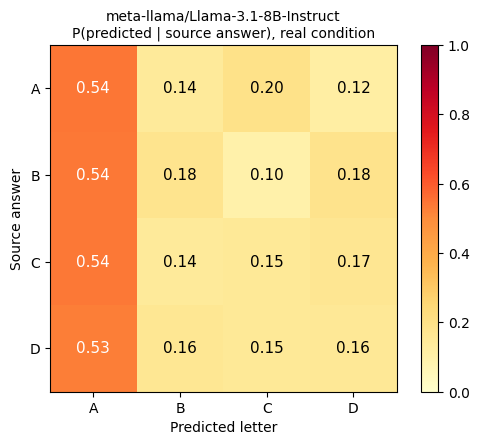

In [14]:
# ── Bias-corrected accuracy: is the match real or just distribution overlap? ──
#
# If the model always predicts A, and the source answers A 50% of the time,
# you'd get 50% "accuracy" from bias alone.  We compute the expected accuracy
# under independence (prediction and answer distributions uncorrelated) and
# compare to the observed accuracy.

if len(sub):
    print(f"=== Bias-corrected letter-match · {PLOT_MODEL_LABEL} ===\n")

    for cond in ["real", "shuffled"]:
        cond_sub = sub[(sub["condition"] == cond) & sub["predicted_letter"].notna()]
        if len(cond_sub) == 0:
            continue

        labels = ["A", "B", "C", "D"]
        # Marginal distributions (as fractions)
        src_counts = cond_sub["source_direct_answer"].value_counts().reindex(labels, fill_value=0)
        pred_counts = cond_sub["predicted_letter"].value_counts().reindex(labels, fill_value=0)
        n = len(cond_sub)
        src_frac = src_counts / n
        pred_frac = pred_counts / n

        # Expected accuracy under independence: sum(P(src=X) * P(pred=X)) for X in ABCD
        expected_acc = sum(src_frac[l] * pred_frac[l] for l in labels)
        observed_acc = cond_sub["matches_source_letter"].mean()
        lift = observed_acc - expected_acc

        print(f"  {cond}:")
        print(f"    observed accuracy = {observed_acc:.3f}")
        print(f"    expected (bias-only, independent) = {expected_acc:.3f}")
        print(f"    lift above bias = {lift:+.3f}")
        print(f"    → {'REAL SIGNAL' if lift > 0.02 else 'mostly bias' if lift > 0 else 'below bias'}")
        print()

    # Per source_persona
    print(f"--- Per source_persona (real condition) ---\n")
    real_with_letter = sub[(sub["condition"] == "real") & sub["predicted_letter"].notna()]
    for sp_name, sp_group in real_with_letter.groupby("source_persona"):
        src_counts = sp_group["source_direct_answer"].value_counts().reindex(labels, fill_value=0)
        pred_counts = sp_group["predicted_letter"].value_counts().reindex(labels, fill_value=0)
        n = len(sp_group)
        src_frac = src_counts / n
        pred_frac = pred_counts / n
        expected_acc = sum(src_frac[l] * pred_frac[l] for l in labels)
        observed_acc = sp_group["matches_source_letter"].mean()
        lift = observed_acc - expected_acc
        print(f"  {sp_name}: observed={observed_acc:.3f}  bias_expected={expected_acc:.3f}  lift={lift:+.3f}")
    print()

    # Confusion matrix
    print(f"=== Confusion matrix (real, has_letter) · {PLOT_MODEL_LABEL} ===\n")
    real_with_letter = sub[(sub["condition"] == "real") & sub["predicted_letter"].notna()].copy()
    confusion = pd.crosstab(
        real_with_letter["source_direct_answer"],
        real_with_letter["predicted_letter"],
        margins=True,
    )
    print(confusion.to_string())
    print()
    display(confusion)

    # Normalized confusion (row-wise: for each source answer, what fraction was predicted as each letter?)
    confusion_norm = pd.crosstab(
        real_with_letter["source_direct_answer"],
        real_with_letter["predicted_letter"],
        normalize="index",
    ).round(3)
    print("Row-normalized (P(predicted | source_answer)):")
    print(confusion_norm.to_string())
    print()
    display(confusion_norm)

    # Heatmap of normalized confusion
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(confusion_norm.values, cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(confusion_norm.columns)))
    ax.set_xticklabels(confusion_norm.columns)
    ax.set_yticks(range(len(confusion_norm.index)))
    ax.set_yticklabels(confusion_norm.index)
    ax.set_xlabel("Predicted letter")
    ax.set_ylabel("Source answer")
    ax.set_title(f"{PLOT_MODEL_LABEL}\nP(predicted | source answer), real condition", fontsize=10)
    for i in range(len(confusion_norm.index)):
        for j in range(len(confusion_norm.columns)):
            val = confusion_norm.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > 0.4 else "black", fontsize=11)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()
else:
    print("No data.")

## Activation impact analysis

The core question: **does injecting the activation actually change what the model predicts?**

If real, shuffled, and baseline all predict the same letter distribution (e.g. always "A"), the activation injection is doing nothing — the identity prompt's own token bias dominates. We test this three ways:

1. **Prediction distribution by condition** — side-by-side comparison of what letters each condition produces.
2. **Per-question prediction shifts** — for each question, does the real activation change the predicted letter vs baseline?
3. **Conditional accuracy on shifted predictions** — when the activation DOES shift the prediction away from baseline, is the new prediction correct more often than chance?

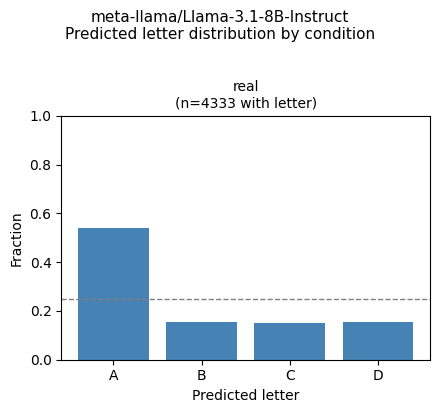

In [15]:
# ── 1. Predicted letter distribution: real vs baseline vs shuffled ──────
# If all three conditions produce the same distribution, the activation
# injection has no effect — the identity prompt's letter bias dominates.

if len(sub):
    import matplotlib.pyplot as plt
    import numpy as np

    labels = ["A", "B", "C", "D"]
    conditions = [c for c in ["real", "text_only_baseline", "shuffled"] if c in sub["condition"].values]
    letter_rows = sub[sub["predicted_letter"].notna()].copy()

    fig, axes = plt.subplots(1, len(conditions), figsize=(4.5 * len(conditions), 4), sharey=True)
    if len(conditions) == 1:
        axes = [axes]

    for ax, cond in zip(axes, conditions):
        cond_rows = letter_rows[letter_rows["condition"] == cond]
        counts = cond_rows["predicted_letter"].value_counts().reindex(labels, fill_value=0)
        frac = counts / counts.sum() if counts.sum() > 0 else counts
        ax.bar(labels, frac, color="steelblue")
        ax.axhline(0.25, color="gray", ls="--", lw=1, label="uniform")
        ax.set_title(f"{cond}\n(n={len(cond_rows)} with letter)", fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Predicted letter")
        if ax == axes[0]:
            ax.set_ylabel("Fraction")

    fig.suptitle(f"{PLOT_MODEL_LABEL}\nPredicted letter distribution by condition", fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()

    # Chi-squared test: are the distributions different?
    from scipy.stats import chi2_contingency
    if len(conditions) >= 2:
        contingency = pd.DataFrame({
            cond: letter_rows[letter_rows["condition"] == cond]["predicted_letter"]
                  .value_counts().reindex(labels, fill_value=0)
            for cond in conditions
        })
        if contingency.sum().sum() > 0:
            chi2, p, dof, _ = chi2_contingency(contingency.values.T)
            print(f"Chi-squared test (are prediction distributions different across conditions?):")
            print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.2e}")
            print(f"  → {'Distributions DIFFER' if p < 0.05 else 'No significant difference — activation may not be changing predictions'}")
else:
    print("No data.")

In [16]:
# ── 2. Per-question prediction shifts: real vs baseline (or shuffled) ────
# For each (question, source_persona, reporter, layers) tuple, check whether
# the real activation changed the predicted letter vs the control condition.
# Falls back to shuffled if text_only_baseline is not present.

if len(sub):
    import matplotlib.pyplot as plt

    keys = ["question_id", "source_persona", "reporter_persona", "source_layer", "injection_layer"]

    # Pick the best available control condition
    if "text_only_baseline" in sub["condition"].values:
        control_cond = "text_only_baseline"
    elif "shuffled" in sub["condition"].values:
        control_cond = "shuffled"
    else:
        control_cond = None

    if control_cond is None:
        print("No baseline or shuffled condition in data — enable controls in patchscope.yaml and re-run.")
    else:
        real_preds = (
            sub[sub["condition"] == "real"][[*keys, "predicted_letter", "source_direct_answer"]]
            .rename(columns={"predicted_letter": "pred_real"})
        )
        ctrl_preds = (
            sub[sub["condition"] == control_cond][[*keys, "predicted_letter"]]
            .rename(columns={"predicted_letter": "pred_ctrl"})
        )

        paired = real_preds.merge(ctrl_preds, on=keys, how="inner")
        paired = paired[paired["pred_real"].notna() & paired["pred_ctrl"].notna()]

        if len(paired) > 0:
            paired["shifted"] = paired["pred_real"] != paired["pred_ctrl"]
            paired["real_correct"] = paired["pred_real"] == paired["source_direct_answer"]
            paired["ctrl_correct"] = paired["pred_ctrl"] == paired["source_direct_answer"]

            n_total = len(paired)
            n_shifted = paired["shifted"].sum()
            n_stayed = n_total - n_shifted

            print(f"=== Prediction shifts: real vs {control_cond} · {PLOT_MODEL_LABEL} ===")
            print(f"  Total paired rows: {n_total}")
            print(f"  Predictions that CHANGED: {n_shifted} ({n_shifted/n_total:.1%})")
            print(f"  Predictions that STAYED:  {n_stayed} ({n_stayed/n_total:.1%})")
            print()

            shifted_df = paired[paired["shifted"]]
            if len(shifted_df) > 0:
                wrong_to_right = ((~shifted_df["ctrl_correct"]) & shifted_df["real_correct"]).sum()
                right_to_wrong = (shifted_df["ctrl_correct"] & (~shifted_df["real_correct"])).sum()
                wrong_to_wrong = ((~shifted_df["ctrl_correct"]) & (~shifted_df["real_correct"])).sum()
                right_to_right = (shifted_df["ctrl_correct"] & shifted_df["real_correct"]).sum()
                print(f"  Among shifted predictions:")
                print(f"    wrong→RIGHT (activation helped):  {wrong_to_right}")
                print(f"    right→WRONG (activation hurt):    {right_to_wrong}")
                print(f"    wrong→wrong (changed, still bad): {wrong_to_wrong}")
                print(f"    right→right (changed, still ok):  {right_to_right}")
                print()

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

            ax1.pie([n_stayed, n_shifted], labels=[f"Same as {control_cond}", "Changed"],
                    colors=["lightgray", "steelblue"], autopct="%1.0f%%", startangle=90)
            ax1.set_title(f"Did activation change the prediction?\n(n={n_total})")

            acc_real = paired["real_correct"].mean()
            acc_ctrl = paired["ctrl_correct"].mean()
            bars = ax2.bar([control_cond, "Real activation"], [acc_ctrl, acc_real],
                           color=["salmon", "steelblue"])
            ax2.axhline(0.25, color="gray", ls="--", lw=1)
            ax2.set_ylabel("Letter-match accuracy")
            ax2.set_ylim(0, max(0.6, max(acc_real, acc_ctrl) + 0.1))
            ax2.set_title(f"Accuracy: {control_cond} vs real\n(paired, n={n_total})")
            for bar, val in zip(bars, [acc_ctrl, acc_real]):
                ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.1%}",
                         ha="center", fontsize=11)

            fig.suptitle(PLOT_MODEL_LABEL, fontsize=11, y=1.02)
            fig.tight_layout()
            plt.show()
        else:
            print(f"Could not pair real and {control_cond} rows (no overlap on keys, or no letters extracted).")
            print(f"  real rows: {len(sub[sub['condition'] == 'real'])}")
            print(f"  {control_cond} rows: {len(sub[sub['condition'] == control_cond])}")
            print(f"  Unique conditions in data: {sub['condition'].unique().tolist()}")
else:
    print("No data.")

No baseline or shuffled condition in data — enable controls in patchscope.yaml and re-run.


In [17]:
# ── 3. Conditional accuracy: shifted vs unshifted predictions ──────────
# If the activation carries real information, rows where it CHANGED the
# prediction should be more accurate than rows where it didn't.

if len(sub) and 'paired' in dir() and len(paired) > 0 and 'shifted' in paired.columns:
    print(f"=== Conditional accuracy · {PLOT_MODEL_LABEL} ===")
    print()

    for label, mask in [("shifted (activation changed prediction)", paired["shifted"]),
                         ("unshifted (same as control)", ~paired["shifted"])]:
        subset = paired[mask]
        if len(subset) == 0:
            print(f"  {label}: no rows")
            continue
        acc = subset["real_correct"].mean()
        print(f"  {label}:")
        print(f"    n={len(subset)}, accuracy={acc:.1%} (chance=25%)")

    print()
    shifted_acc = paired.loc[paired["shifted"], "real_correct"].mean() if paired["shifted"].any() else 0
    unshifted_acc = paired.loc[~paired["shifted"], "real_correct"].mean() if (~paired["shifted"]).any() else 0
    if shifted_acc > unshifted_acc + 0.05:
        print("  → Shifted predictions are MORE accurate: activation is carrying useful signal.")
    elif shifted_acc < unshifted_acc - 0.05:
        print("  → Shifted predictions are LESS accurate: activation may be injecting noise.")
    else:
        print("  → Similar accuracy whether shifted or not: inconclusive.")

    if paired["shifted"].any():
        shifted_df = paired[paired["shifted"]]
        print(f"\n=== Transition matrix (control→real) for shifted rows ===")
        trans = pd.crosstab(
            shifted_df["pred_ctrl"].rename("control"),
            shifted_df["pred_real"].rename("real"),
            margins=True
        )
        print(trans.to_string())
        display(trans)
else:
    print("No paired data available — enable text_only_baseline or shuffled_activation in patchscope.yaml and re-run.")

No paired data available — enable text_only_baseline or shuffled_activation in patchscope.yaml and re-run.


### Interpretation guide

**Letter-match accuracy** is the primary metric for the identity prompt format. The pattern-echo output (`N -> N; ...`) is expected — it's the prompt design. What matters is whether answer letters leak through the echo and match the source's answer.

Key comparisons:
- **real vs chance (25%)**: Does the patched activation carry answer information at all?
- **real vs shuffled**: Is the information specific to this question, or generic?
- **same-persona vs cross-persona pairs**: Does the reporter decode better when it shares the source's persona? (PSM signal)
- **Layer pair variation**: Which extraction → injection layer combinations carry the most signal? Mid-to-late extraction layers typically work best.

### Next steps

- Try **wrong-persona, same-question** control (patches activation from a different persona answering the same question) to isolate persona-specific signal from content signal.
- Add **random noise** control (Gaussian, norm-matched) as a sanity check.
- For free-form experiments: switch to a descriptive template and use LLM-judge or embedding similarity for evaluation.